<a href="https://colab.research.google.com/github/SAISANJAYR/Sai-s_IQube_Practice_Tasks/blob/main/Sai's_IQube_Practice_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sai's IQube Practice-Notebook**

## 1. **Day-1** *(Types of Data & Descriptive Statistics)*

**Task:** Create a list of 8–10 student exam scores. Manually compute the mean, median, mode,
variance, and standard deviation. Then verify your results using NumPy and SciPy. Finally, add
an extreme outlier (e.g., 0 or 100) and observe how each measure changes.

In [ ]:
student_marks = [70, 83, 86, 71, 97, 76, 86]

mean = sum(student_marks)/len(student_marks)
print(f"Mean of the marks (manual calc): {mean}\n")

sorted_marks = sorted(student_marks)
if len(student_marks) % 2 != 0:
  median = sorted_marks[len(student_marks)//2]
else:
  median = (sorted_marks[len(student_marks)//2 - 1] + sorted_marks[len(student_marks)//2])/2
print(f"Median of the marks (manual calc): {median}\n")

# Recalculate mean as student_marks is now sorted and might be used for other calculations
# if using in-place sort, but with sorted(), student_marks remains original
# For variance, n should be defined as the number of elements
n = len(student_marks)
var_sum = sum([(x - mean)**2 for x in student_marks])
variance = var_sum/n
print(f"Variance of the marks (manual calc): {variance}\n")

std_deviation = variance**(1/2)
print(f"Standard deviation of the marks (manual calc): {std_deviation}\n")

Mean of the marks (manual calc): 81.28571428571429

Median of the marks (manual calc): 83

Variance of the marks (manual calc): 79.34693877551021

Standard deviation of the marks (manual calc): 8.907689867497083



In [ ]:
import numpy as np
import scipy as sp

mean_np = np.mean(student_marks)
print(f"Mean of the marks (np): {mean_np}\n")

median_np = np.median(student_marks)
print(f"Median of the marks (np): {median_np}\n")

variance_np = np.var(student_marks)
print(f"Variance of the marks (np): {variance_np}\n")

std_dev_np = np.std(student_marks)
print(f"Standard deviation of the marks (np): {std_dev_np}\n")

Mean of the marks (np): 81.28571428571429

Median of the marks (np): 83.0

Variance of the marks (np): 79.34693877551021

Standard deviation of the marks (np): 8.907689867497083



## 2. **Day-2** *(Probability Fundamentals)*

**Task:** Visualize the binomial distribution using matplotlib for different values of n (10, 20, 50) and p
(0.2, 0.5, 0.8). Place all 9 combinations in a 3×3 grid subplot. Observe: When does the
distribution look symmetric? When is it skewed? What happens as n increases?

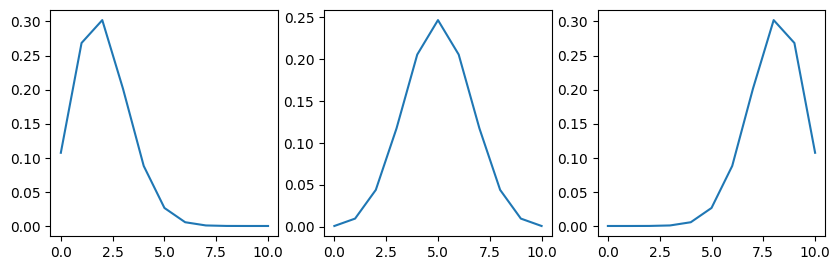

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import binom

plt.figure(figsize=(10, 10))

n1, p1 = 10, 0.2
pmf = binom.pmf(range(n1 + 1), n1, p1)
plt.subplot(3, 3, 1)
plt.plot(range(n1+1), pmf)

p2 = 0.5
pmf = binom.pmf(range(n1 + 1), n1, p2)
plt.subplot(3, 3, 2)
plt.plot(range(n1+1), pmf)

p3 = 0.8
pmf = binom.pmf(range(n1 + 1), n1, p3)
plt.subplot(3, 3, 3)
plt.plot(range(n1+1), pmf)



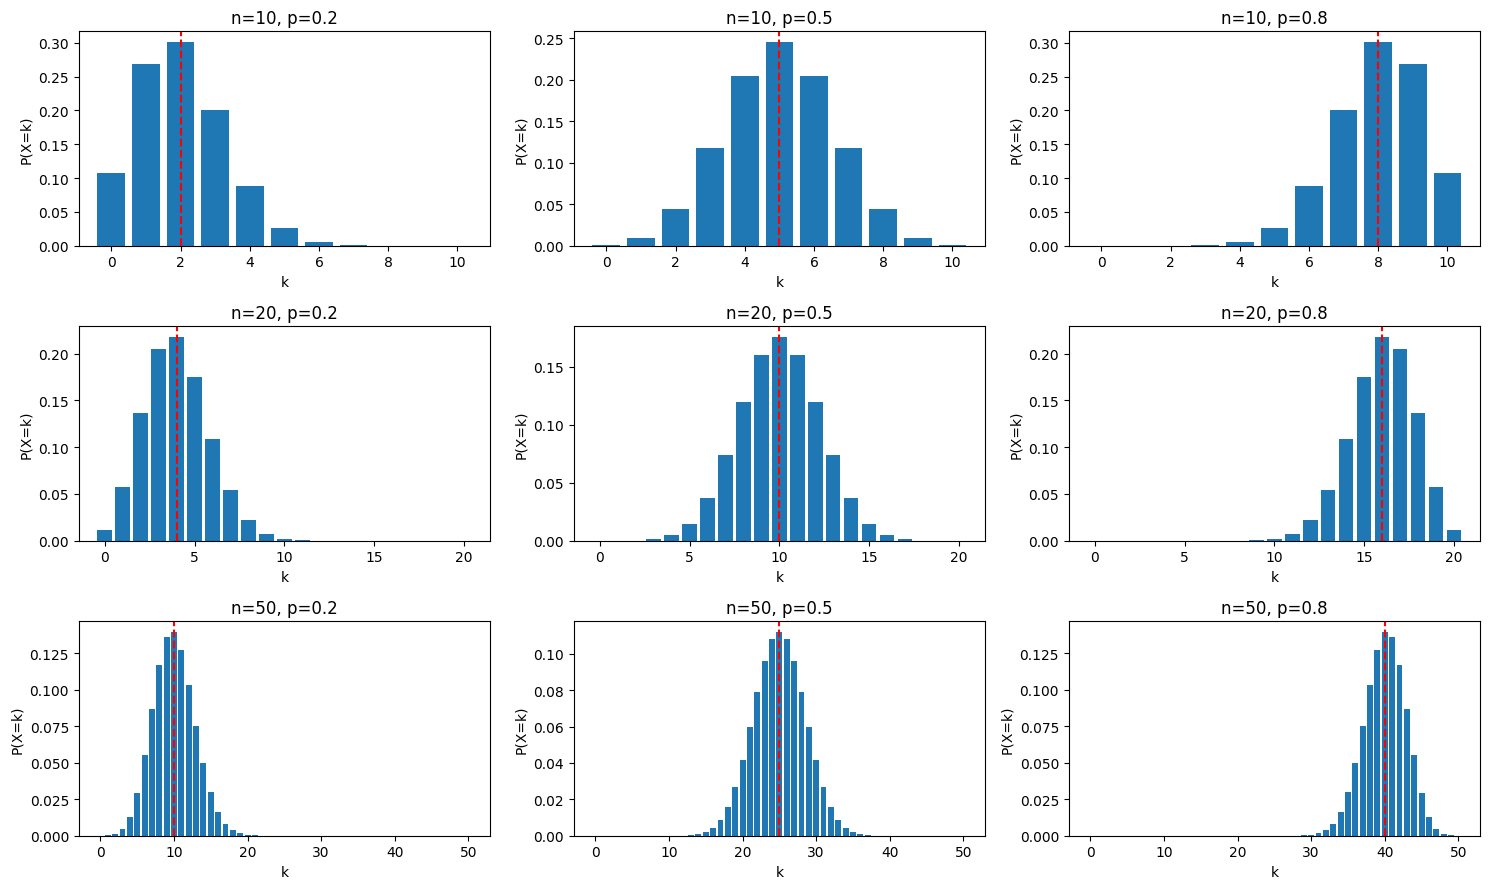

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n_values = [10, 20, 50]
p_values = [0.2, 0.5, 0.8]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))

for i, n in enumerate(n_values):
    for j, p in enumerate(p_values):
        ax = axes[i, j]

        x = np.arange(0, n + 1)
        pmf = binom.pmf(x, n, p)

        ax.bar(x, pmf)

        mean = n * p
        ax.axvline(mean, color = 'red', linestyle='--')

        ax.set_title(f'n={n}, p={p}')
        ax.set_xlabel('k')
        ax.set_ylabel('P(X=k)')

plt.tight_layout()
plt.show()

## 3. **Day-3** *(Normal Distribution & Sampling)*

**Task:** Simulate the Central Limit Theorem: Generate a population from an exponential distribution
(heavily right-skewed). Draw 1000 samples each of size n=5, n=15, and n=30. Plot the
distribution of sample means for each. Watch the normal bell curve emerge as n increases!

Text(0.5, 1.0, 'Sample Mean Distribution (n=30)')

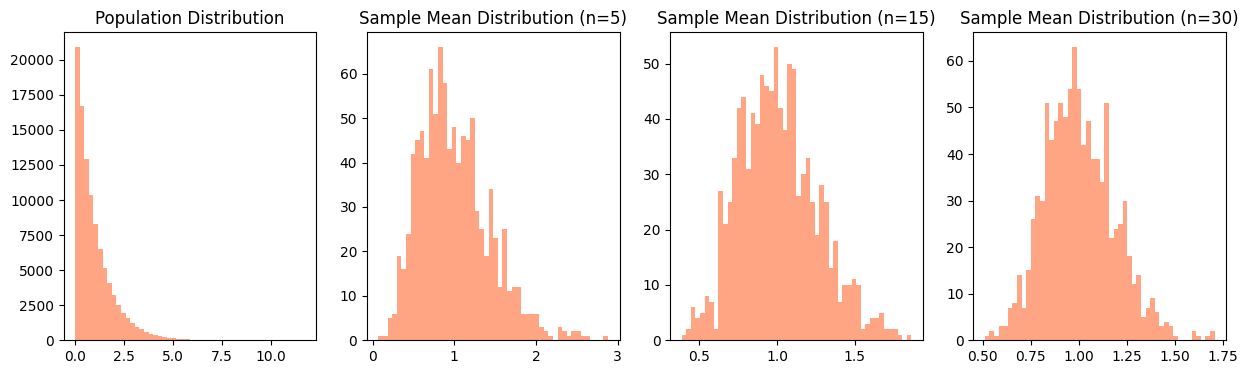

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
population = np.random.exponential(size=100000)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].hist(population, bins=50, color='coral', alpha=0.7)
axes[0].set_title('Population Distribution')

sample_mean_n5 = [np.mean(np.random.choice(population, 5)) for _ in range(1000)]
axes[1].hist(sample_mean_n5, bins=50, color='coral', alpha=0.7)
axes[1].set_title('Sample Mean Distribution (n=5)')

sample_mean_n15 = [np.mean(np.random.choice(population, 15)) for _ in range(1000)]
axes[2].hist(sample_mean_n15, bins=50, color='coral', alpha=0.7)
axes[2].set_title('Sample Mean Distribution (n=15)')

sample_mean_n30 = [np.mean(np.random.choice(population, 30)) for _ in range(1000)]
axes[3].hist(sample_mean_n30, bins=50, color='coral', alpha=0.7)
axes[3].set_title('Sample Mean Distribution (n=30)')


## 4. **Day-4** *(Hypothesis Testing & Correlation)*

**Task:** Load the Titanic dataset. Run a two-sample t-test comparing the ages of survivors vs.
non-survivors. State your H0 and H1 clearly. Interpret the p-value and conclude. Then compute
the Pearson and Spearman correlation between Age and Fare. Discuss why they might differ.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Null Hypothesis: No significant age difference between groups")
print("Alternative Hypothesis: Age DOES differ significantly between survivors and non-survivors")

survivors = df[df['Survived']==1]['Age'].dropna()
non_survivors = df[df['Survived']==0]['Age'].dropna()

t_stat, p_value = stats.ttest_ind(survivors, non_survivors, equal_var=False)

print(f"\nt_statistic: {t_stat:.3f}")
print(f"p_value: {p_value:.4f}")

print("\nConclusion:")

alpha = 0.05
if p_value < alpha:
  print("\nAge DOES differ significantly between survivors and non-survivors")
else:
  print("\nNo significant age difference between groups")

Null Hypothesis: No significant age difference between groups
Alternative Hypothesis: Age DOES differ significantly between survivors and non-survivors

t_statistic: -2.046
p_value: 0.0412

Conclusion:

Age DOES differ significantly between survivors and non-survivors


In [ ]:
# Correlation analysis
df_filtered = df[['Age', 'Fare']].dropna()
age = df_filtered['Age']
fare = df_filtered['Fare']

r_pearson, p_pearson = stats.pearsonr(age, fare)
print(f'Pearson r = {r_pearson:.3f}, p = {p_pearson:.4f}')

r_spearman, p_spearman = stats.spearmanr(age, fare)
print(f'Spearman r = {r_spearman:.3f}, p = {p_spearman:.4f}')

Pearson r = 0.096, p = 0.0102
Spearman r = 0.135, p = 0.0003


**Note:** The low p values suggests a very weak relation between `Age` & `Fare`

Text(0, 0.5, 'Fare')

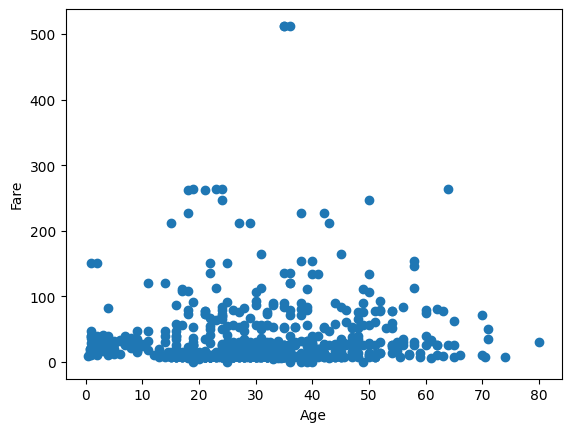

In [ ]:
plt.scatter(age, fare)
plt.xlabel('Age')
plt.ylabel('Fare')

## 5. **Day-5** *(Data Wrangling with Pandas)*

**Task:** Load the Titanic dataset. (1) Profile it: check shape, dtypes, and null counts. (2) Handle all
missing values — use median for Age, mode for Embarked, and drop Cabin. (3) Run a GroupBy
to compare survival rates by Pclass. (4) Find the top 5 most expensive tickets using sort_values.

In [ ]:
import numpy as np
import pandas as pd

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}\n")
print(f"Dtypes: {df.dtypes}\n")
print(f"Null counts (Before): {df.isnull().sum()}\n")

# Handling Missing Values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

print(f"Null counts (After): {df.isnull().sum()}\n")

Shape: (891, 12)

Dtypes: PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Null counts (Before): PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Null counts (After): PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64



In [ ]:
# Using Groupby
survival_rate_by_class = df.groupby('Pclass')['Survived'].mean()
print(f"Survival rate by class: {survival_rate_by_class}\n")


Survival rate by class: Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64



In [ ]:
# Checking
print(df['Pclass'].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [ ]:
# Ticket Cost
ticket_sorted_df = df.sort_values('Fare', ascending=False)
cols = ['Name', 'Pclass', 'Fare', 'Survived']
print("5 Most Expensive Tickets: ")
print(ticket_sorted_df[cols].head(5).to_string(index=False))

5 Most Expensive Tickets: 
                              Name  Pclass     Fare  Survived
Cardeza, Mr. Thomas Drake Martinez       1 512.3292         1
                  Ward, Miss. Anna       1 512.3292         1
            Lesurer, Mr. Gustave J       1 512.3292         1
        Fortune, Miss. Mabel Helen       1 263.0000         1
                 Fortune, Mr. Mark       1 263.0000         0


##6. **Day-6** *(Data Visualization — Univariate Analysis)*

**Task:** Load the Titanic dataset. (1) Plot the Age distribution using both histogram (bins=20) and KDE
on the same figure. (2) Create a box plot for the Fare column — note the outliers. Apply log
transformation and re-plot. (3) Create a count plot for the Embarked column. Write 2–3
observations under each chart.

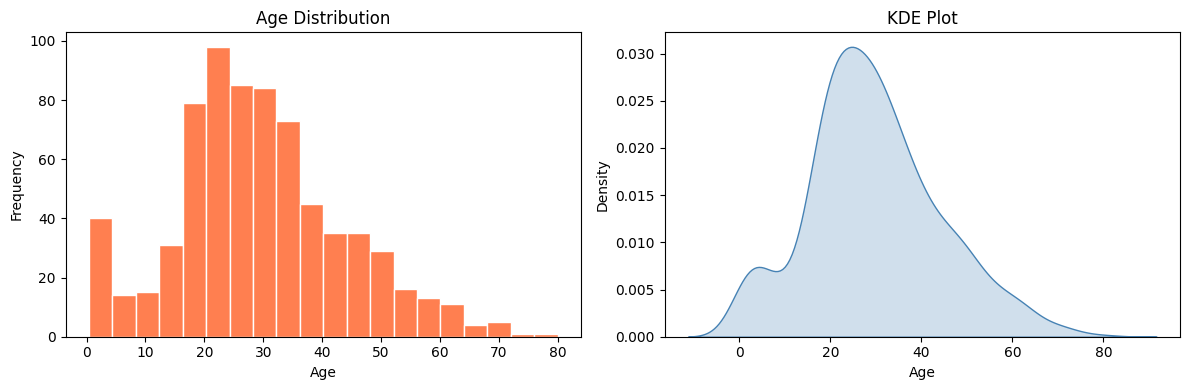

In [ ]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Histogram & KDE plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Age'], bins=20, color='coral', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

sns.kdeplot(df['Age'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('KDE Plot')
axes[1].set_xlabel('Age')
axes[1].set_title('KDE Plot')
plt.tight_layout()
plt.show()

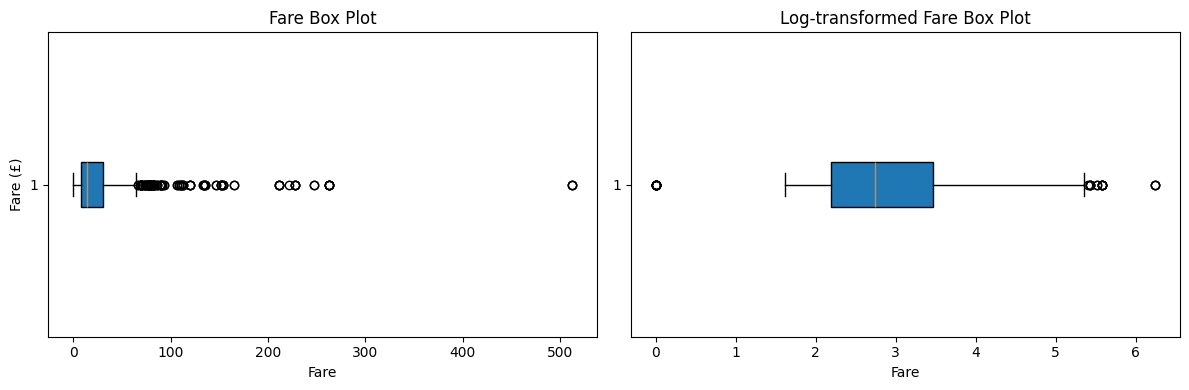

In [ ]:
# Box plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Fare'].dropna(), patch_artist=True,
                vert=False
                )
axes[0].set_title('Fare Box Plot')
axes[0].set_ylabel('Fare (£)')
axes[0].set_xlabel('Fare')

axes[1].boxplot(np.log1p(df['Fare'].dropna()), patch_artist=True,
                vert=False
                )
axes[1].set_title('Log-transformed Fare Box Plot')
axes[1].set_xlabel('Fare')
plt.tight_layout()
plt.show()

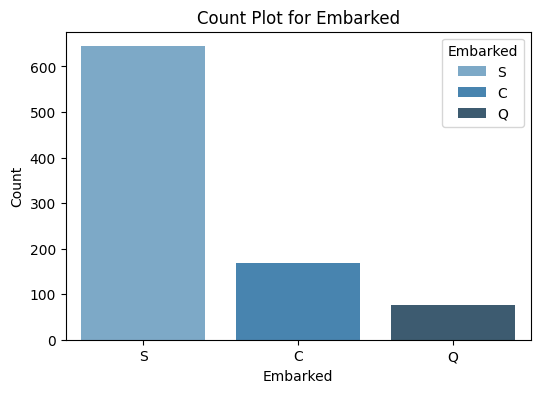

In [ ]:
# Count plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Embarked', data=df, palette='Blues_d',
              hue='Embarked'
              )
plt.title('Count Plot for Embarked')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()

## 7. **Day-7** *(Data Visualization — Bivariate & Multivariate)*

**Task:** Load the Iris dataset (sns.load_dataset('iris')). (1) Build a correlation heatmap — which two
features are most correlated? (2) Create a pairplot with species as hue — which feature pair
best separates the species? (3) Create a violin plot comparing petal_length across species.
Write 2–3 observations for each chart.

<Axes: >

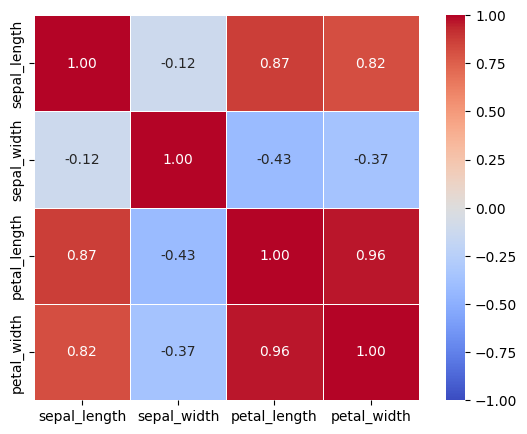

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# HeatMap
iris = sns.load_dataset('iris')

corr_matrix = iris.drop('species', axis=1).corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
vmin=-1, vmax=1, square=True, linewidths=0.5)

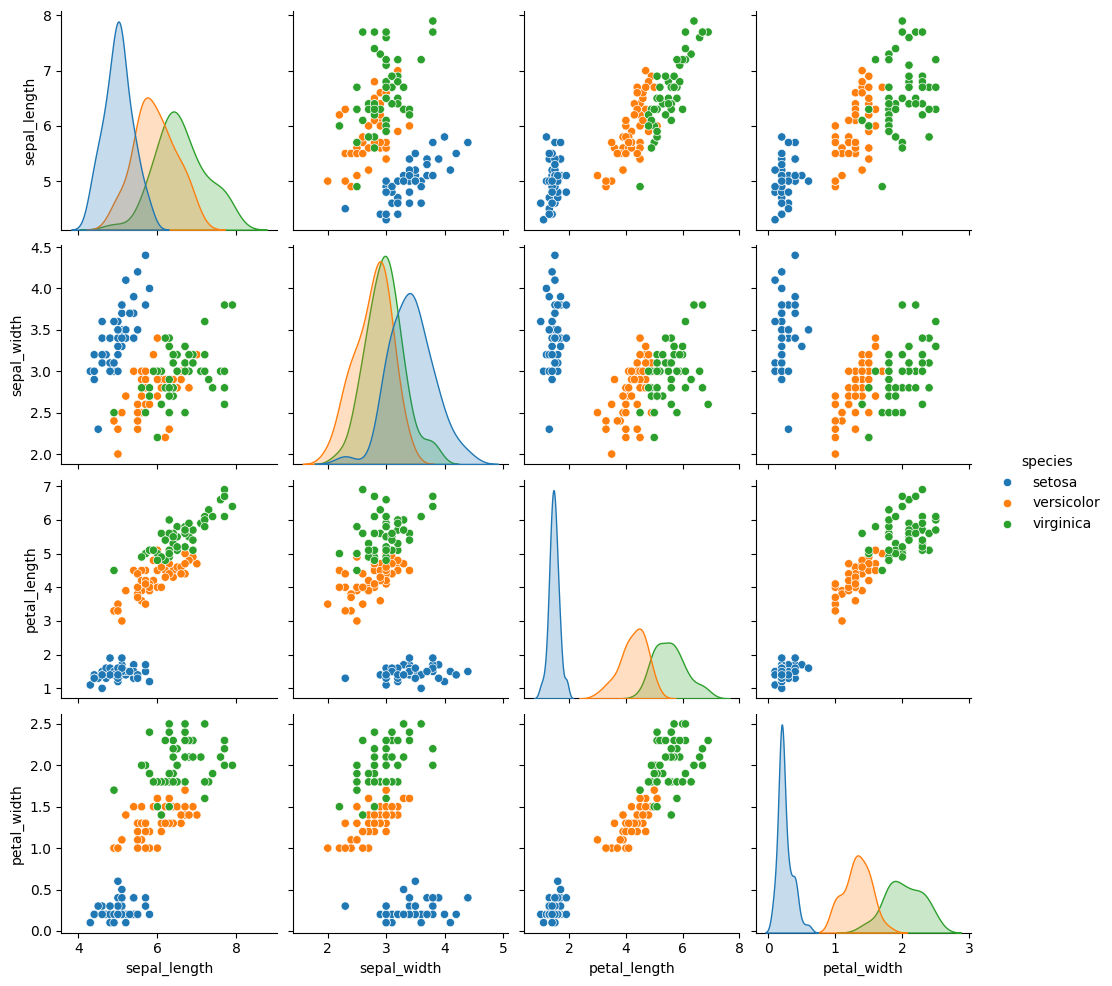

In [ ]:
# PairPlot
sns.pairplot(iris, hue='species')
# Setting hue param automatically uses kde for diagonal plot instead of histogram which is default


Text(0.5, 1.0, 'Violin Plot: Petal Length Across Species')

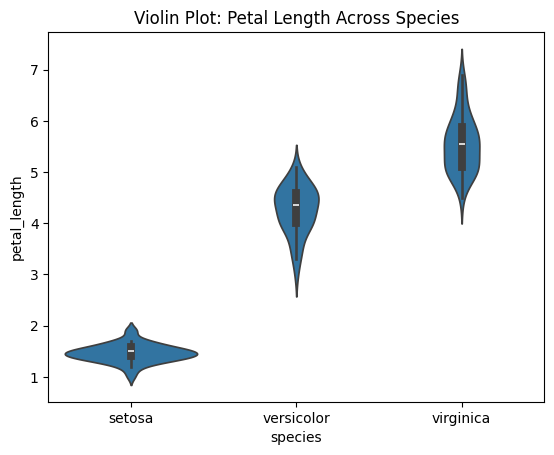

In [ ]:
# ViolinPlot
sns.violinplot(x='species', y='petal_length', data=iris,
               #inner='quartile'
               )
# if inner='quartile' instead of using box plot, it uses lines(quartiles) to show mean, median and extreme points....
plt.title("Violin Plot: Petal Length Across Species")

## 8. **Day-8** *(Outlier Analysis & Feature Understanding)*

**Task:** Load the Ames Housing dataset from Kaggle. (1) Detect outliers in the Gr Liv Area (above-ground
living area) column using both Z-score and IQR methods. How many does each detect? (2)
Visualise the outliers with a box plot and scatter plot. (3) Apply log transformation to Gr Liv Area
and re-visualise.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("/content/AmesHousing.csv")

#df.info()
# Outlier Detection
# Z-score:
z_scores = (np.abs(stats.zscore(df['Gr Liv Area'])) > 3)
print(f"Number of Z-score outliers: {z_scores.sum()}")

# IQR:
Q1 = df['Gr Liv Area'].quantile(0.25)
Q3 = df['Gr Liv Area'].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = (df['Gr Liv Area'] < (Q1 - 1.5 * IQR)) | (df['Gr Liv Area'] > (Q3 + 1.5 * IQR))
print(f"Number of IQR outliers: {iqr_outliers.sum()}")

Number of Z-score outliers: 25
Number of IQR outliers: 75


In [ ]:
print(z_scores[:5])

[False False False False False]


Text(0, 0.5, 'Frequency')

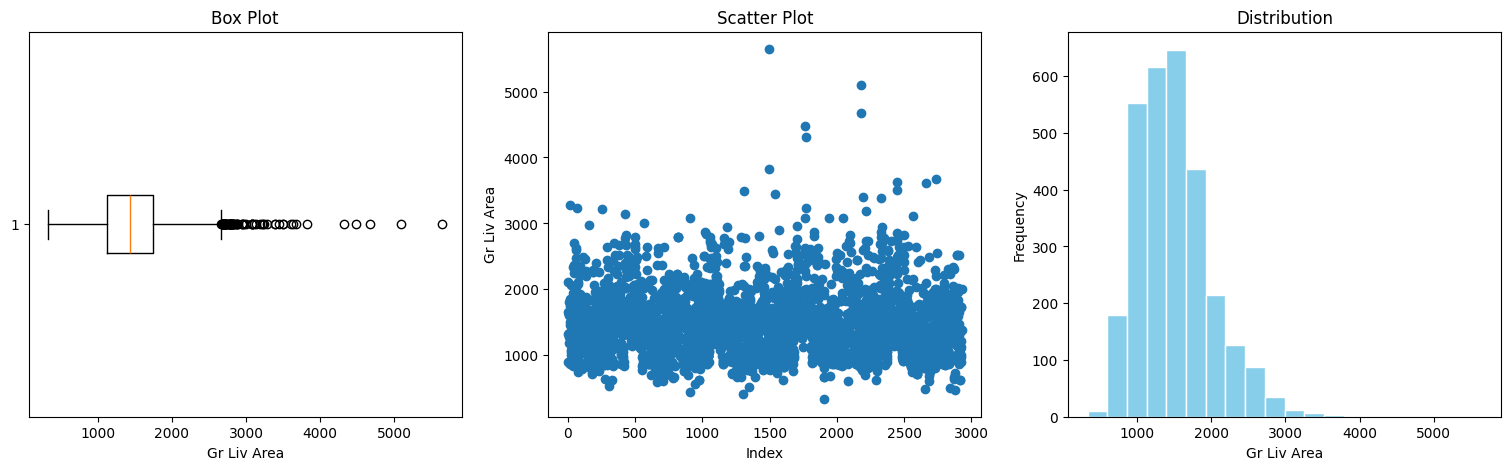

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Box Plot
axes[0].boxplot(df['Gr Liv Area'], vert=False)
axes[0].set_title('Box Plot')
axes[0].set_xlabel('Gr Liv Area')

# Scatter Plot
axes[1].scatter(df.index, df['Gr Liv Area'])
axes[1].set_title('Scatter Plot')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Gr Liv Area')

# Distribution
axes[2].hist(df['Gr Liv Area'], bins=20, color='skyblue', edgecolor='white')
axes[2].set_title('Distribution')
axes[2].set_xlabel('Gr Liv Area')
axes[2].set_ylabel('Frequency')

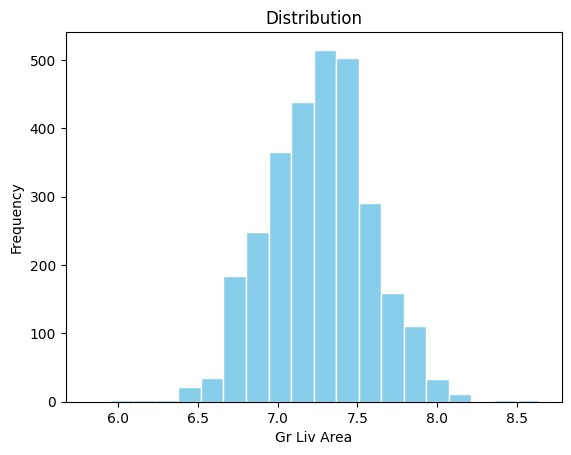

In [ ]:
# Transformation
df['log_GrLivArea'] = np.log1p(df['Gr Liv Area']) # Right skewed data -> Log Transformation

# Visualize
plt.hist(df['log_GrLivArea'], bins=20, color='skyblue', edgecolor='white')
plt.title('Distribution')
plt.xlabel('Gr Liv Area')
plt.ylabel('Frequency')
plt.show()

# 9. **Day-9** *(Exploratory Data Analysis)*

**Task:** Complete a full end-to-end EDA on the Titanic OR Ames Housing dataset in a Jupyter notebook.
Follow all 9 steps in the checklist above. Write at LEAST 3 lines of interpretation below every
single chart you create. At the end, identify 3–5 features you believe would be most predictive
for a machine learning model.

Shape: (891, 12)

Column dtypes:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicates: 0

Describe:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000 

/tmp/ipykernel_4026/1444736832.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_4026/1444736832.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

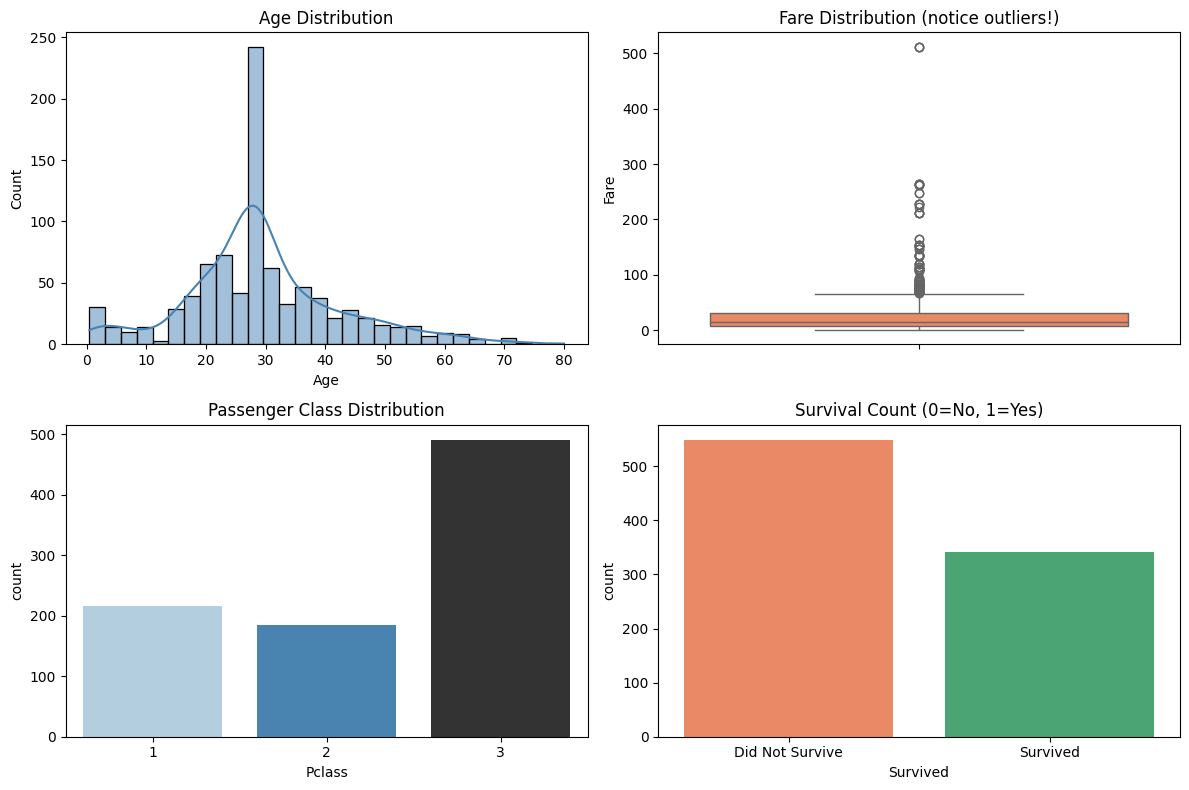

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data Inspection
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print('Shape:', df.shape)  # (891, 12)

print('\nColumn dtypes:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

print('\nDuplicates:', df.duplicated().sum())

print('\nDescribe:')
print(df.describe())

# Cleaning
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop('Cabin', axis=1, inplace=True)  # Too many missing (77%)

# Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Univariate
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Age Distribution')

sns.boxplot(y=df['Fare'], ax=axes[0,1], color='coral')
axes[0,1].set_title('Fare Distribution (notice outliers!)')

sns.countplot(x='Pclass', data=df, ax=axes[1,0],
              hue='Pclass', legend=False, palette='Blues_d')
axes[1,0].set_title('Passenger Class Distribution')

sns.countplot(x='Survived', data=df, ax=axes[1,1],
              hue='Survived', legend=False, palette=['coral', 'mediumseagreen'])
axes[1,1].set_title('Survival Count (0=No, 1=Yes)')
axes[1,1].set_xticklabels(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_4026/2520151968.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Survived', y='Age', data=df, ax=axes[2],
/tmp/ipykernel_4026/2520151968.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Did Not Survive', 'Survived'])


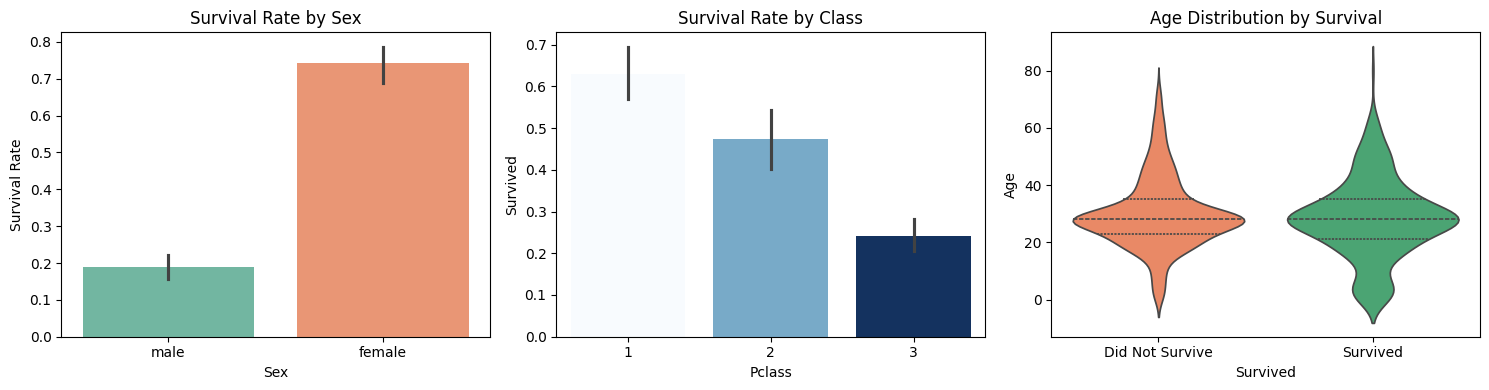

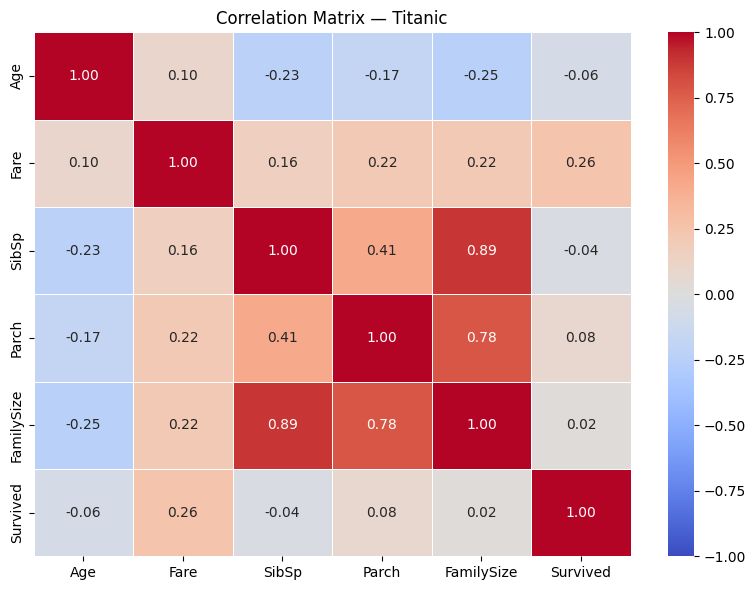

In [3]:
# Bivariate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by Sex
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0],
            hue='Sex', legend=False, palette='Set2')
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1],
            hue='Pclass', legend=False, palette='Blues')
axes[1].set_title('Survival Rate by Class')

sns.violinplot(x='Survived', y='Age', data=df, ax=axes[2],
               palette=['coral', 'mediumseagreen'], inner='quartile')
axes[2].set_title('Age Distribution by Survival')
axes[2].set_xticklabels(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

print(2*'\n')


# Multivariate
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Survived']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Matrix — Titanic')
plt.tight_layout()
plt.show()

